# Fixed Income Analytics: Convexity, ALM Constraints, and Regime Detection

This notebook develops three analytically connected layers of a rates portfolio framework, approached from the perspective of a systematic FX researcher building fixed income intuition from first principles. The mathematical toolkit — Taylor expansions, state-space models, constrained optimisation — translates directly from FX; the economic interpretation is where the asset classes diverge, and that translation is precisely what is documented here.

**Audience:** Quantitative practitioners with a working knowledge of duration, bond pricing, and time-series models.

**Scope:**
1. **Convexity** — second-order correction to DV01-based P&L, and why it matters for large-shock stress testing
2. **NII vs OCI** — the binding ALM constraint governing duration decisions in a bank's investment portfolio
3. **HMM Regime Detection** — applying the hidden Markov framework used in FX vol regime models to identify central bank cycle regimes in rates

*Dependencies:* `numpy`, `matplotlib`, `hmmlearn`, custom `FixedIncome.bonds` analytics module.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from FixedIncome.bonds import compute_dv01, compute_convexity

---
## 1. Convexity: Second-Order Price Sensitivity

DV01 linearises the bond price–yield relationship at the current yield. For small moves (≲ 25 bps) the approximation is adequate. For the large, fat-tailed moves that characterise rate markets during central bank regime shifts — the 2022 hiking cycle delivered 300+ bps in under twelve months — the linear approximation introduces material error.

Convexity is the second-order correction term in the Taylor expansion of bond price with respect to yield:

$$\Delta P \approx -\text{DV01} \cdot \Delta y + \frac{1}{2} \cdot \text{Convexity} \cdot P \cdot (\Delta y)^2$$

The quadratic term is always positive — for both rate rises and falls — because it scales with $(\Delta y)^2$. This structural asymmetry is the defining property of positive convexity: the bond outperforms its DV01 approximation in both directions. From an options perspective, the holder of a convex bond is structurally long gamma on rates.

The test below applies a ±300 bps shock to a 10-year bond (4% coupon, 4.5% YTM) — a range that captures the tail scenarios most relevant for stress testing a rates book.

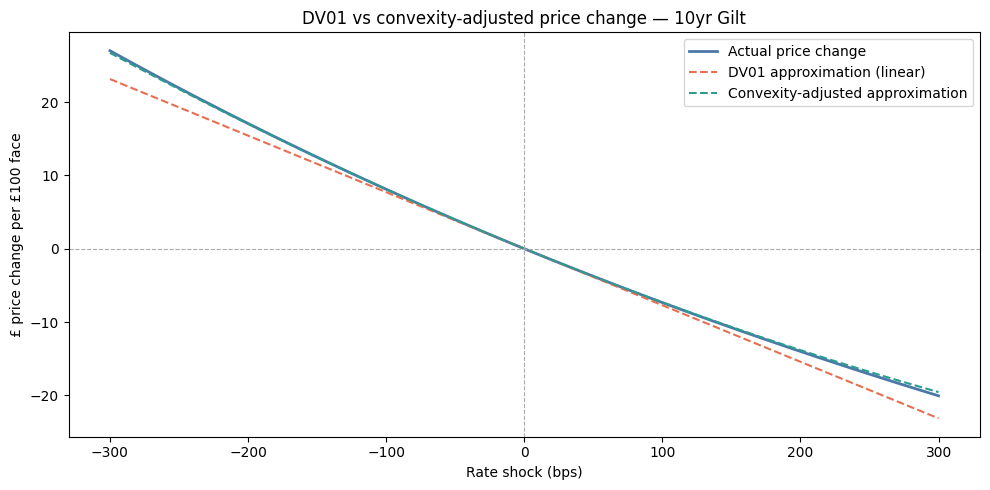

In [8]:
# --- Compare DV01 vs convexity-adjusted price change ---
shock_range = range(-300, 301, 10)  # -300 to +300 bps

bond = {"face": 100, "coupon_rate": 0.04, "ytm": 0.045, "years": 10}

dv01       = compute_dv01(bond["face"], bond["coupon_rate"], bond["ytm"], bond["years"])
convexity  = compute_convexity(bond["face"], bond["coupon_rate"], bond["ytm"], bond["years"])

def bond_price(face, coupon_rate, ytm, years):
    cash_flows = [face * coupon_rate] * years
    cash_flows[-1] += face
    return sum(cf / (1 + ytm) ** (t + 1) for t, cf in enumerate(cash_flows))

price_0 = bond_price(**bond)

actual_changes  = []
dv01_approx     = []
convex_approx   = []

for shock in shock_range:
    dy = shock / 10000
    actual  = bond_price(bond["face"], bond["coupon_rate"], 
                         bond["ytm"] + dy, bond["years"]) - price_0
    linear  = -dv01 * shock
    convex  = -dv01 * shock + 0.5 * convexity * dy ** 2 * 100

    actual_changes.append(actual)
    dv01_approx.append(linear)
    convex_approx.append(convex)

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(shock_range, actual_changes, label="Actual price change",
         color="#4C78A8", linewidth=2)
plt.plot(shock_range, dv01_approx,   label="DV01 approximation (linear)",
         color="#E76F51", linestyle="--")
plt.plot(shock_range, convex_approx, label="Convexity-adjusted approximation",
         color="#2A9D8F", linestyle="--")
plt.axhline(0, color="#AAAAAA", linewidth=0.8, linestyle="--")
plt.axvline(0, color="#AAAAAA", linewidth=0.8, linestyle="--")
plt.title("DV01 vs convexity-adjusted price change — 10yr Gilt")
plt.xlabel("Rate shock (bps)")
plt.ylabel("£ price change per £100 face")
plt.legend()
plt.tight_layout()
plt.show()

**Takeaway:** The DV01 approximation (red dashed) systematically overstates losses on the sell-off and understates gains on the rally — the classic signature of positive convexity. The convexity-adjusted approximation (green dashed) tracks the actual price curve closely across the full ±300 bps range; residual error beyond ±200 bps reflects higher-order terms. A portfolio manager relying solely on DV01 for a 300 bps stress scenario will misstate the P&L by a non-trivial margin. For bonds with embedded options (callables, MBS), where convexity can turn negative, this error compounds further — making second-order risk attribution non-negotiable in a serious rates book.

---
## 2. NII vs OCI: The ALM Constraint Surface

In a bank's investment portfolio (the banking book), the CIO desk faces a constraint with no direct analogue in a pure asset manager's mandate: net interest income (NII) and other comprehensive income (OCI) move in opposite directions as duration increases, and both feed into reported financials and regulatory capital.

**NII** is the running yield earned on the portfolio. Under an upward-sloping curve, longer-dated bonds pay more — extending duration directly increases NII.

**OCI** is the mark-to-market reserve account for Available-for-Sale (AFS) securities under IFRS 9. When rates rise, bond prices fall, and the loss flows through OCI — reducing equity reserves directly, without touching the income statement. Duration drives OCI sensitivity: a 10-year bond absorbs roughly 8–9× the OCI impact of a 1-year instrument on the same notional.

The CIO mandate is, effectively, to maximise NII subject to OCI volatility constraints, regulatory capital thresholds (Basel III CET1), and liquidity requirements. Duration is the primary lever — but there is no free lunch. Extending duration picks up NII while simultaneously increasing OCI exposure. The optimal point depends on the rate view, which is precisely where regime detection becomes actionable.

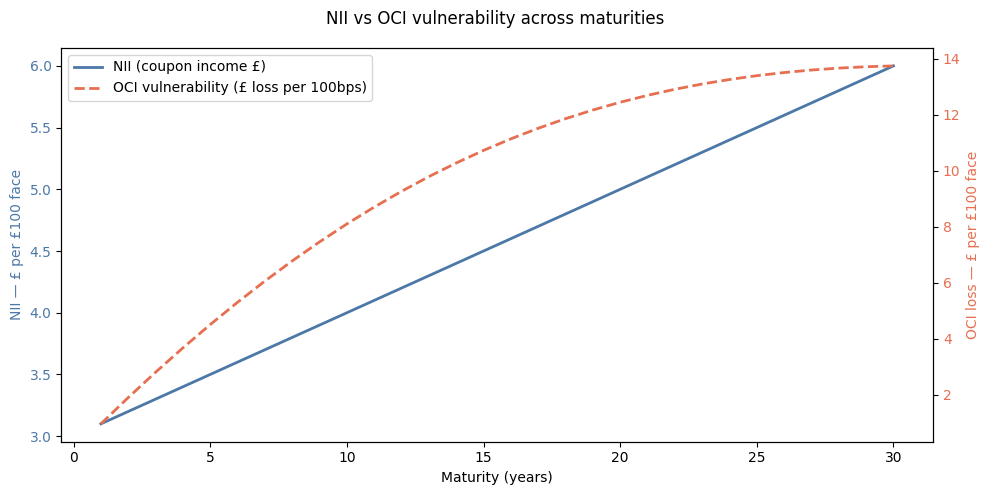

In [9]:
# --- Parameters ---
maturities  = np.arange(1, 31)   # 1 to 30 years
risk_free   = 0.03                # base rate 3%
spread      = 0.001               # 0.1bp per year of maturity (upward sloping curve)
shock_bps   = 100                 # rate shock for OCI vulnerability

# --- NII proxy: coupon income = ytm * face ---
# Longer bonds have higher yields on upward sloping curve
ytms        = risk_free + spread * maturities
nii         = ytms * 100          # £ per £100 face, annualised

# --- OCI vulnerability: DV01 * shock ---
dv01s       = np.array([
    compute_dv01(100, ytms[i], ytms[i], int(maturities[i]))
    for i in range(len(maturities))
])
oci_impact  = abs(dv01s) * shock_bps

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(maturities, nii, color="#4C78A8", linewidth=2, label="NII (coupon income £)")
ax1.set_xlabel("Maturity (years)")
ax1.set_ylabel("NII — £ per £100 face", color="#4C78A8")
ax1.tick_params(axis="y", labelcolor="#4C78A8")

ax2 = ax1.twinx()
ax2.plot(maturities, oci_impact, color="#E76F51", linewidth=2,
         linestyle="--", label="OCI vulnerability (£ loss per 100bps)")
ax2.set_ylabel("OCI loss — £ per £100 face", color="#E76F51")
ax2.tick_params(axis="y", labelcolor="#E76F51")

fig.suptitle("NII vs OCI vulnerability across maturities")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

**Takeaway:** NII scales near-linearly with maturity — the yield curve pickup is gradual and relatively predictable. OCI vulnerability accelerates non-linearly, reflecting the convexity of DV01 itself with respect to maturity: each additional year of duration adds incrementally more price sensitivity. The two curves diverge sharply beyond the 10-year point, where incremental NII per unit of OCI risk deteriorates rapidly. For most banking book portfolios operating under capital and OCI volatility constraints, the 5–10 year segment offers the most efficient trade-off — meaningful yield pickup without extreme exposure to a parallel shift. This sweet spot shifts with the rate view: in a hiking regime, the efficient frontier compresses toward shorter maturities.

---
## 3. HMM Regime Detection: From FX to Rates

Hidden Markov Models are a standard tool in systematic FX — applied to volatility regime identification, carry vs. momentum switching, and positioning signal conditioning. The mathematical framework is identical when applied to rates; the economic interpretation of the regimes differs.

In FX, regimes are defined by volatility clustering and risk appetite: risk-on (low vol, carry dominant) vs. risk-off (high vol, momentum or safe-haven flows). Features are typically FX return distributions, realised vol, or cross-asset correlations.

In rates, regimes map to the central bank cycle: **range-bound** (policy on hold, low return variance, rates anchored) vs. **trending** (hiking or cutting cycle, directional drift, elevated variance). The economic content of the regime labels changes, but the inference problem is structurally identical — unobserved discrete state, Gaussian emissions, first-order Markov transitions.

Baum-Welch (EM) estimates the transition matrix and emission parameters from the observed return series. Viterbi decoding recovers the most probable hidden state sequence. The connection to the ALM framework above is direct: regime detection answers *when* to extend or shorten duration; the NII/OCI surface answers *by how much* and at what cost to the constraint set.

Model is not converging.  Current: 1109.535988642665 is not greater than 1109.536459666505. Delta is -0.0004710238399638911


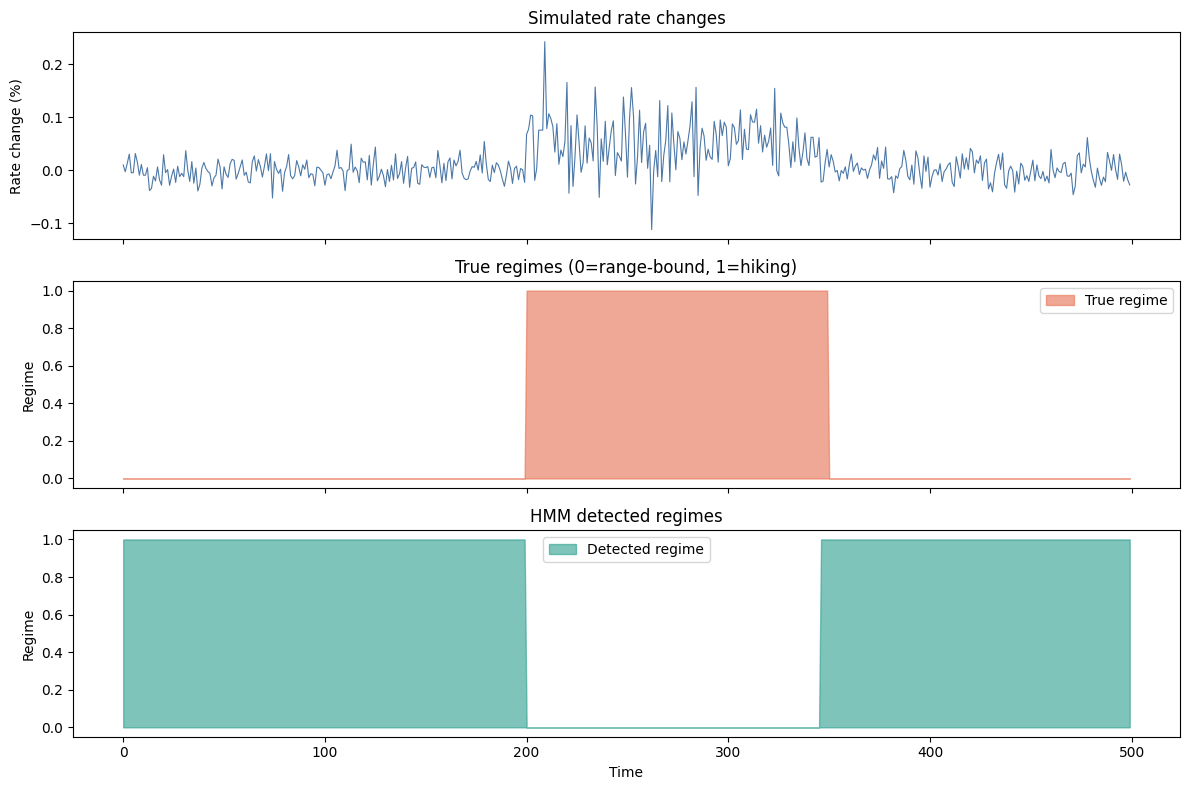

Transition matrix:
[[0.993 0.007]
 [0.003 0.997]]

Means per regime:
  Regime 0: mean return = 0.0537
  Regime 1: mean return = -0.0002


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

# --- Simulate a rate series with two regimes ---
# Regime 0: range-bound (low vol, rates sideways)
# Regime 1: hiking cycle (higher vol, rates trending up)
np.random.seed(42)

n_samples = 500
regime_changes = [0] * 200 + [1] * 150 + [0] * 150

returns = []
true_regimes = []
for regime in regime_changes:
    if regime == 0:
        returns.append(np.random.normal(0, 0.02))    # low vol, mean zero
    else:
        returns.append(np.random.normal(0.05, 0.05)) # higher vol, upward drift
    true_regimes.append(regime)

returns = np.array(returns).reshape(-1, 1)

# --- Fit Gaussian HMM ---
model = GaussianHMM(n_components=2, covariance_type="full", n_iter=100)
model.fit(returns)
hidden_states = model.predict(returns)

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Rate returns
axes[0].plot(returns, color="#4C78A8", linewidth=0.8)
axes[0].set_title("Simulated rate changes")
axes[0].set_ylabel("Rate change (%)")

# True regimes
axes[1].fill_between(range(len(true_regimes)), true_regimes,
                     alpha=0.6, color="#E76F51", label="True regime")
axes[1].set_title("True regimes (0=range-bound, 1=hiking)")
axes[1].set_ylabel("Regime")
axes[1].legend()

# Detected regimes
axes[2].fill_between(range(len(hidden_states)), hidden_states,
                     alpha=0.6, color="#2A9D8F", label="Detected regime")
axes[2].set_title("HMM detected regimes")
axes[2].set_ylabel("Regime")
axes[2].set_xlabel("Time")
axes[2].legend()

plt.tight_layout()
plt.show()

# --- Print transition matrix ---
print("Transition matrix:")
print(np.round(model.transmat_, 3))
print("\nMeans per regime:")
for i, mean in enumerate(model.means_):
    print(f"  Regime {i}: mean return = {mean[0]:.4f}")

**Takeaway:** The HMM recovers the regime structure accurately in this simulation. The key diagnostic is the transition matrix: diagonal elements represent regime persistence — a $p(\text{stay} \mid \text{hiking}) \approx 0.9$ implies an expected regime duration of ~10 periods, warranting sustained short-duration positioning rather than tactical hedges that get whipsawed by noise. In practice, HMM-decoded regimes exhibit a detection lag of 5–10 observations — inherent to any filtering approach that requires sufficient evidence before updating state probabilities. This latency makes the signal appropriate for strategic duration tilts (weeks to months) rather than intraday positioning. When combined with the NII/OCI surface, the output is a regime-conditional duration target: the model specifies both the direction and the cost.

---
## Synthesis: A Layered Rates Framework

These three analyses are not independent — they form a coherent, layered framework for managing interest rate risk in a fixed income portfolio.

**Layer 1 — Convexity** refines the price sensitivity model. DV01 is adequate for small moves and first-order attribution; convexity is necessary for stress testing, large-shock scenario analysis, and understanding the asymmetric P&L profile of the portfolio. Without it, risk is systematically misstated in tail scenarios — precisely the scenarios that matter most.

**Layer 2 — NII/OCI** defines the constraint surface within which duration decisions must be made. In a banking book context, the objective is not unconstrained return maximisation — it is NII maximisation subject to OCI volatility, capital adequacy, and liquidity constraints. Duration is the dial; the NII/OCI trade-off curve describes the cost of turning it.

**Layer 3 — HMM Regime Detection** provides the conditioning signal. It answers the timing question the NII/OCI framework leaves open: given the current rate environment, should duration be extended or compressed? The regime probability output from the HMM is a natural input to a dynamic duration allocation model sitting on top of the ALM constraint surface.

From a systematic FX perspective, this architecture maps to a familiar structure: convexity is analogous to gamma management in an options book; NII/OCI is analogous to the carry vs. drawdown constraint in an FX strategy; regime detection is the signal filter that conditions position sizing. Different asset class — same analytical architecture.